## 1. Import Necessary Libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 2. Import Dataset

In [2]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [5]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [6]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

### 4.1 Data Cleaning

In [3]:
claimants_data.dropna(inplace = True)

In [9]:
1340-1096

244

In [12]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [14]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Seperate your inputs and Outputs

In [4]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis = 1,)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [5]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

### 5.1 Model Validation Techniques - Train Test Split

In [145]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20,shuffle=True, random_state=34,)

### 5.2 KFold CV

In [151]:
from sklearn.model_selection import KFold,cross_val_score

kfold = KFold(n_splits=5,shuffle=True, random_state=123)

cv_scores = cross_val_score(estimator = logistic_model,X = X,y=y,cv=kfold)

print(cv_scores)
print("Overall Accuracy:", cv_scores.mean().round(2))
print("Overall Std.Deviation:", cv_scores.std().round(2))

[0.68636364 0.71232877 0.72146119 0.71689498 0.68949772]
Overall Accuracy: 0.71
Overall Accuracy: 0.01


### 5.3 LOOCV

In [154]:
from sklearn.model_selection import LeaveOneOut
loocv = LeaveOneOut()

cv_scores = cross_val_score(estimator = logistic_model,X = X,y=y,cv=loocv)

print(cv_scores)
print("Overall Accuracy:", cv_scores.mean().round(2))
print("Overall Std.Deviation:", cv_scores.std().round(2))

[1. 1. 1. ... 1. 1. 1.]
Overall Accuracy: 0.7
Overall Std.Deviation: 0.46


In [77]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [84]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
627,1.0,1.0,0.0,40.0,6.337
1125,1.0,1.0,0.0,37.0,4.609
1124,1.0,1.0,0.0,46.0,0.730
1025,1.0,1.0,0.0,38.0,3.406
481,1.0,1.0,0.0,70.0,0.566
...,...,...,...,...,...
658,0.0,1.0,0.0,14.0,4.479
1257,0.0,1.0,0.0,7.0,0.453
1015,1.0,0.0,0.0,69.0,3.110
1114,1.0,1.0,0.0,0.0,7.169


## 6. Model Training

In [93]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier

In [7]:
logistic_model = LogisticRegression()

In [117]:
rf_classifier = RandomForestClassifier(n_estimators=75,max_depth=5,criterion='entropy',)
rf_classifier.fit(X_train,y_train)

,n_estimators,75
,criterion,'entropy'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
ada_boost_classifer =  AdaBoostClassifier()
ada_boost_classifer.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [106]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [80]:
dt_model = DecisionTreeClassifier(criterion='entropy',max_depth=None)

### Stacking Technique

In [139]:
from sklearn.neighbors import KNeighborsClassifier

In [144]:
logistic_classfier = LogisticRegression()
dt_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators = [("logistic_model",logistic_classfier),
                                                   ("dt_model",dt_classifier),
                                                   ("knn_model",knn_classifier)])
voting_classifier.fit(X,y)

y_pred = voting_classifier.predict(X)

accuracy_score(y,y_pred)

0.8394160583941606

### Grid Search CV(Cross Validation)

In [116]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator  = rf_classifier,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                                    "criterion":['gini','entropy'],
                                                                    "n_estimators":[50,75,100,150]})
grid_search.fit(X,y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 75}
0.7326359485263595


In [81]:
dt_model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


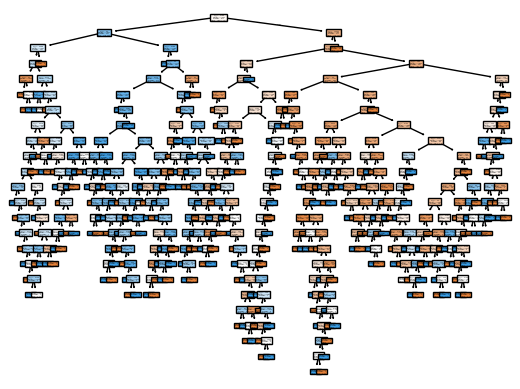

In [83]:
#plt.figure( figsize = (8, 10),)
plot_tree(decision_tree = dt_model,filled=True)#,fontsize=,filled=True)
plt.show()

## 7. Model Testing

### Training Data

In [129]:
y_pred_train = rf_classifier.predict(X_train)
y_pred_train

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

### Test Data

In [130]:
y_pred_test = rf_classifier.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## 8. Model Evaluation

In [131]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### 8.1 Training Data's Evaluation Metrics

In [132]:
print(confusion_matrix(y_train, y_pred_train))

[[357  96]
 [124 299]]


In [133]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       453
           1       0.76      0.71      0.73       423

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



### ROC Curve - Receiver Operating Characteristics

##### AUC - Area Under this Curve

0.7474676310804254


Text(0, 0.5, 'True Positive Rate')

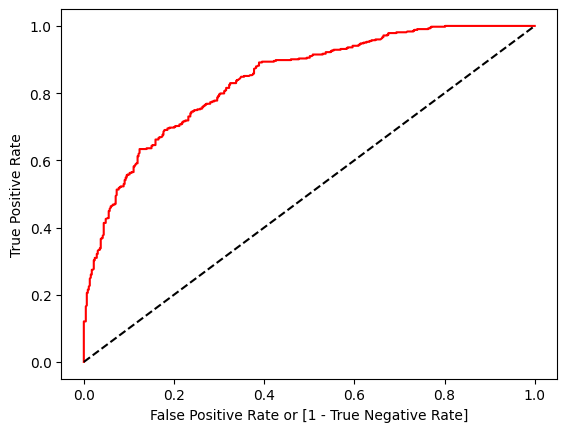

In [134]:
fpr, tpr, thresholds = roc_curve(y_train, rf_classifier.predict_proba (X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### 8.2 Test Data's Evaluation Metrics

In [135]:
accuracy_score(y_test, y_pred_test)

0.7227272727272728

In [136]:
print(confusion_matrix(y_test, y_pred_test))

[[94 31]
 [30 65]]


In [137]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76       125
           1       0.68      0.68      0.68        95

    accuracy                           0.72       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.72      0.72      0.72       220



0.7181052631578948


Text(0, 0.5, 'True Positive Rate')

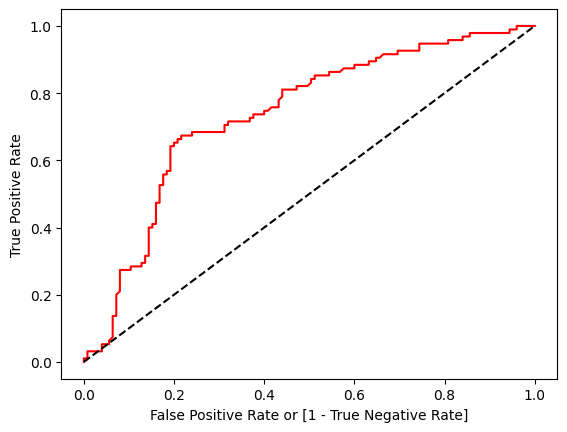

In [138]:
fpr, tpr, thresholds = roc_curve(y_test, rf_classifier.predict_proba (X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## BIAS - VARIANCE

* Training Error/Accuracy - Bias
* Test Error/Accuracy - Variance.

### Model Overfitting - Less Bias and High Variance.
### Model Underfitting - High Bias and Less Variance.

### EXPECTED MODEL -- GENERALIZED MODEL - Less Bias and Less Variance.

So, there is always a **Tradeoff maintaned between Bias and Variance.**

## 9. Model Deployment

In [39]:
from pickle import dump

In [40]:
dump(logistic_model,open("claimaints.pkl","wb"))

## THE END!!